# K-Nearest Neighbors (KNN): Non-Parametric Classification

Unlike Logistic Regression or Perceptrons, KNN does not assume the data can be separated by a line. Instead, it relies on the **Local Density** of the data.

## Key Hyperparameter: $K$
- **Small $K$ (e.g., $K=1$):** The boundary is very complex and follows the noise in the data (Overfitting).
- **Large $K$:** The boundary becomes smoother as it averages out more neighbors (Underfitting).

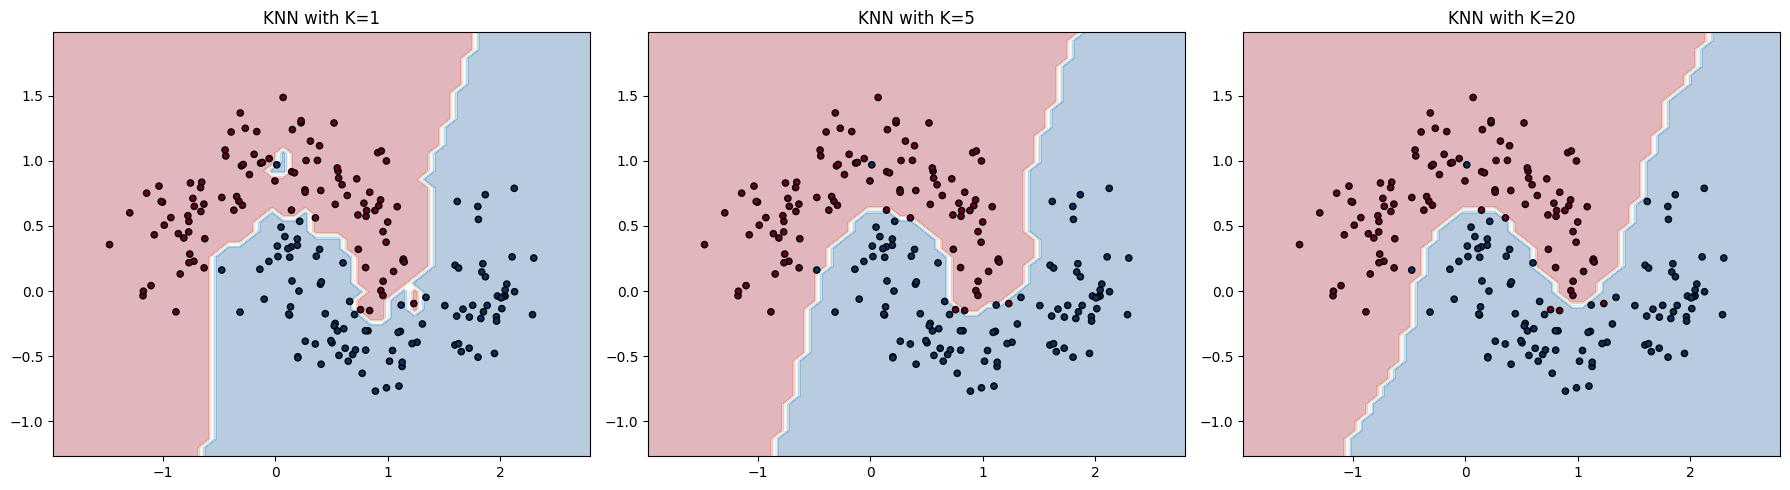

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mlpackage.supervised_learning import KNN
from sklearn.datasets import make_moons

# 1. Generate Non-Linear Data (Moons dataset)
X, y = make_moons(n_samples=200, noise=0.2, random_state=42)

# 2. Visualize different K values
ks = [1, 5, 20]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, k in enumerate(ks):
    model = KNN(k=k)
    model.fit(X, y)
    
    # Create Meshgrid
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 50),
                         np.linspace(y_min, y_max, 50))
    
    # Predict over grid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot
    axes[i].contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    axes[i].scatter(X[:, 0], X[:, 1], c=y, s=20, edgecolor='k', cmap='RdBu')
    axes[i].set_title(f'KNN with K={k}')

plt.tight_layout()
plt.show()